# Taller 1.2 — Clasificación Binaria con Regresión Logística
## Potabilidad del Agua

**Universidad Andina del Cusco — Escuela Profesional de Ingeniería de Sistemas**
**Curso:** Inteligencia Artificial (2026-II) · **Docente:** Hugo Espetia Huamanga

**Integrantes:**
- Coavoy Cruz, Joseph Gabriel — [Código]
- Cuchuyrrumi Mamani, Manuel Rodrigo — [Código]
- Huallpatuiro Rafaile, Brayan — [Código]
- Mamani Acuña, Frank Joseph — [Código]

Este cuaderno documenta, paso a paso, el proceso completo pedido en el enunciado
(`Taller 1.2.docx`): desde el planteamiento del problema hasta la exportación del
modelo entrenado para el aplicativo web. Es la misma lógica que implementa
`train_model.py`, aquí explicada con más detalle y con cada salida intermedia
visible (tablas, gráficos, métricas), para sustentar las decisiones tomadas en
cada fase.

**Índice**
1. Planteamiento del problema
2. Carga y exploración de datos (EDA)
3. Preprocesamiento
4. Modelado con Regresión Logística
5. Evaluación de métricas
6. Exportación del modelo (despliegue)
7. Conclusiones

## 1. Planteamiento del problema

El acceso a agua potable segura es un indicador crítico de salud pública.
Confirmar la potabilidad de una muestra mediante ensayos de laboratorio
completos es costoso y lento; un modelo que estime la potabilidad a partir de
parámetros fisicoquímicos de rutina podría servir como una primera capa de
*triage*: priorizar qué muestras requieren análisis de laboratorio urgente, o
alertar sobre posibles fuentes de agua no aptas para consumo.

El problema se plantea como una **clasificación binaria mutuamente
excluyente**, análoga al clásico "Perros vs. Gatos" que menciona el enunciado:

- **Clase 0 — No potable:** el agua no cumple los estándares de consumo humano.
- **Clase 1 — Potable:** el agua es apta para consumo humano.

**Dataset:** [*Water Potability*](https://www.kaggle.com/datasets/adityakadiwal/water-potability)
(Kaggle), 3276 muestras, 9 variables fisicoquímicas predictoras, sin variables
categóricas.

In [1]:
import json

import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, f1_score,
    precision_score, recall_score, roc_auc_score, roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

DESCRIPCION = {
    "ph": "pH del agua (0-14, ideal 6.5-8.5)",
    "Hardness": "Dureza - capacidad de precipitar jabon (mg/L)",
    "Solids": "Solidos disueltos totales (ppm)",
    "Chloramines": "Cloraminas - desinfectante residual (ppm)",
    "Sulfate": "Sulfatos disueltos (mg/L)",
    "Conductivity": "Conductividad electrica (uS/cm)",
    "Organic_carbon": "Carbono organico total (ppm)",
    "Trihalomethanes": "Trihalometanos - subproducto de cloracion (ug/L)",
    "Turbidity": "Turbidez - material en suspension (NTU)",
}

## 2. Carga y exploración de datos (EDA)

### 2.1 Carga del dataset y primer vistazo

In [2]:
df = pd.read_csv("water_potability.csv")
FEATURES = [c for c in df.columns if c != "Potability"]
TARGET = "Potability"

print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")
df.head()

Dimensiones: 3276 filas x 10 columnas


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [3]:
pd.DataFrame({
    "descripcion": DESCRIPCION,
    "tipo": df[FEATURES].dtypes.astype(str),
    "min": df[FEATURES].min().round(2),
    "max": df[FEATURES].max().round(2),
})

,descripcion,tipo,min,max
ph,"pH del agua (0-14, ideal 6.5-8.5)",float64,0.00,14.00
Hardness,Dureza - capacidad de precipitar jabon (mg/L),float64,47.43,323.12
Solids,Solidos disueltos totales (ppm),float64,320.94,61227.20
Chloramines,Cloraminas - desinfectante residual (ppm),float64,0.35,13.13
Sulfate,Sulfatos disueltos (mg/L),float64,129.00,481.03
Conductivity,Conductividad electrica (uS/cm),float64,181.48,753.34
Organic_carbon,Carbono organico total (ppm),float64,2.20,28.30
Trihalomethanes,Trihalometanos - subproducto de cloracion (ug/L),float64,0.74,124.00
Turbidity,Turbidez - material en suspension (NTU),float64,1.45,6.74


In [4]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
ph,2785.0,7.08,1.59,0.00,6.09,7.04,8.06,14.00
Hardness,3276.0,196.37,32.88,47.43,176.85,196.97,216.67,323.12
Solids,3276.0,22014.09,8768.57,320.94,15666.69,20927.83,27332.76,61227.20
Chloramines,3276.0,7.12,1.58,0.35,6.13,7.13,8.11,13.13
Sulfate,2495.0,333.78,41.42,129.00,307.70,333.07,359.95,481.03
Conductivity,3276.0,426.21,80.82,181.48,365.73,421.88,481.79,753.34
Organic_carbon,3276.0,14.28,3.31,2.20,12.07,14.22,16.56,28.30
Trihalomethanes,3114.0,66.40,16.18,0.74,55.84,66.62,77.34,124.00
Turbidity,3276.0,3.97,0.78,1.45,3.44,3.96,4.50,6.74
Potability,3276.0,0.39,0.49,0.00,0.00,0.00,1.00,1.00


### 2.2 Calidad de los datos: nulos, duplicados y balance de clases

In [5]:
nulos = df[FEATURES].isna().sum()
nulos_pct = (nulos / len(df) * 100).round(1)
pd.DataFrame({"nulos": nulos, "% del total": nulos_pct}).sort_values("nulos", ascending=False)

,nulos,% del total
Sulfate,781,23.8
ph,491,15.0
Trihalomethanes,162,4.9
Solids,0,0.0
Hardness,0,0.0
Chloramines,0,0.0
Conductivity,0,0.0
Organic_carbon,0,0.0
Turbidity,0,0.0


In [6]:
print(f"Filas duplicadas: {df.duplicated().sum()}")

balance = df[TARGET].value_counts().sort_index()
balance_pct = (balance / len(df) * 100).round(1)
pd.DataFrame({
    "clase": ["0 - No potable", "1 - Potable"],
    "muestras": balance.values,
    "%": balance_pct.values,
})

Filas duplicadas: 0


,clase,muestras,%
0,0 - No potable,1998,61.0
1,1 - Potable,1278,39.0


**Hallazgo:** tres variables tienen valores faltantes — `ph` (15.0%), `Sulfate`
(23.8%) y `Trihalomethanes` (4.9%) — que se resolverán por imputación en el
preprocesamiento (sección 3). No hay filas duplicadas. El desbalance de clases
es moderado (61% / 39%), pero suficiente para afectar el entrenamiento si no se
compensa (ver sección 4.2).

### 2.3 Visualización exploratoria

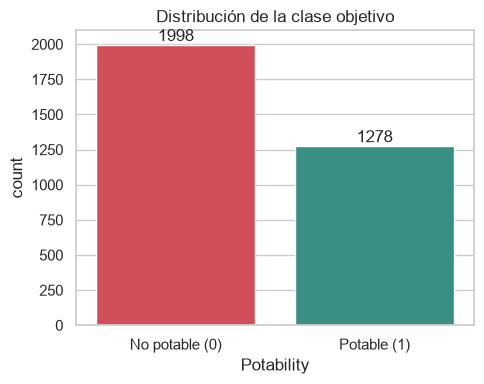

In [7]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x=TARGET, data=df, hue=TARGET, palette=["#e63946", "#2a9d8f"], legend=False, ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels(["No potable (0)", "Potable (1)"])
ax.set_title("Distribución de la clase objetivo")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")
plt.tight_layout()
plt.show()

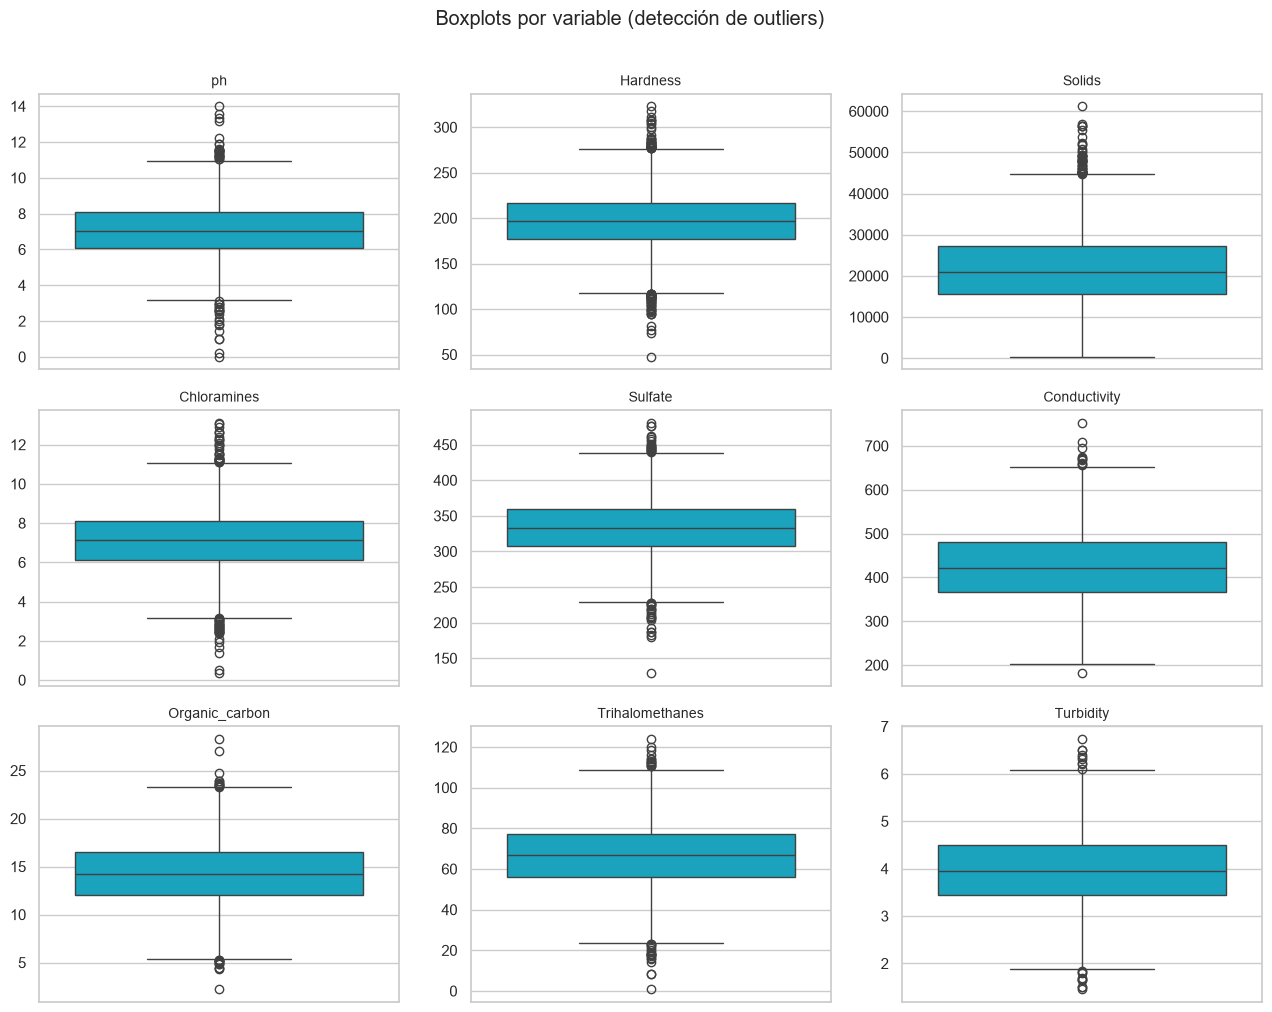

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(13, 10))
for ax, col in zip(axes.flat, FEATURES):
    sns.boxplot(y=df[col], ax=ax, color="#00b4d8")
    ax.set_title(col, fontsize=10)
    ax.set_ylabel("")
plt.suptitle("Boxplots por variable (detección de outliers)", y=1.01)
plt.tight_layout()
plt.show()

El método IQR (1.5×RIC) confirma valores atípicos en todas las variables,
siendo `Hardness`, `Chloramines` y `Solids` las más afectadas. Se optó por
**no eliminarlos**: en un problema de calidad de agua, un valor extremo puede
ser una señal real (contaminación, fuente atípica) y no necesariamente un
error de medición.

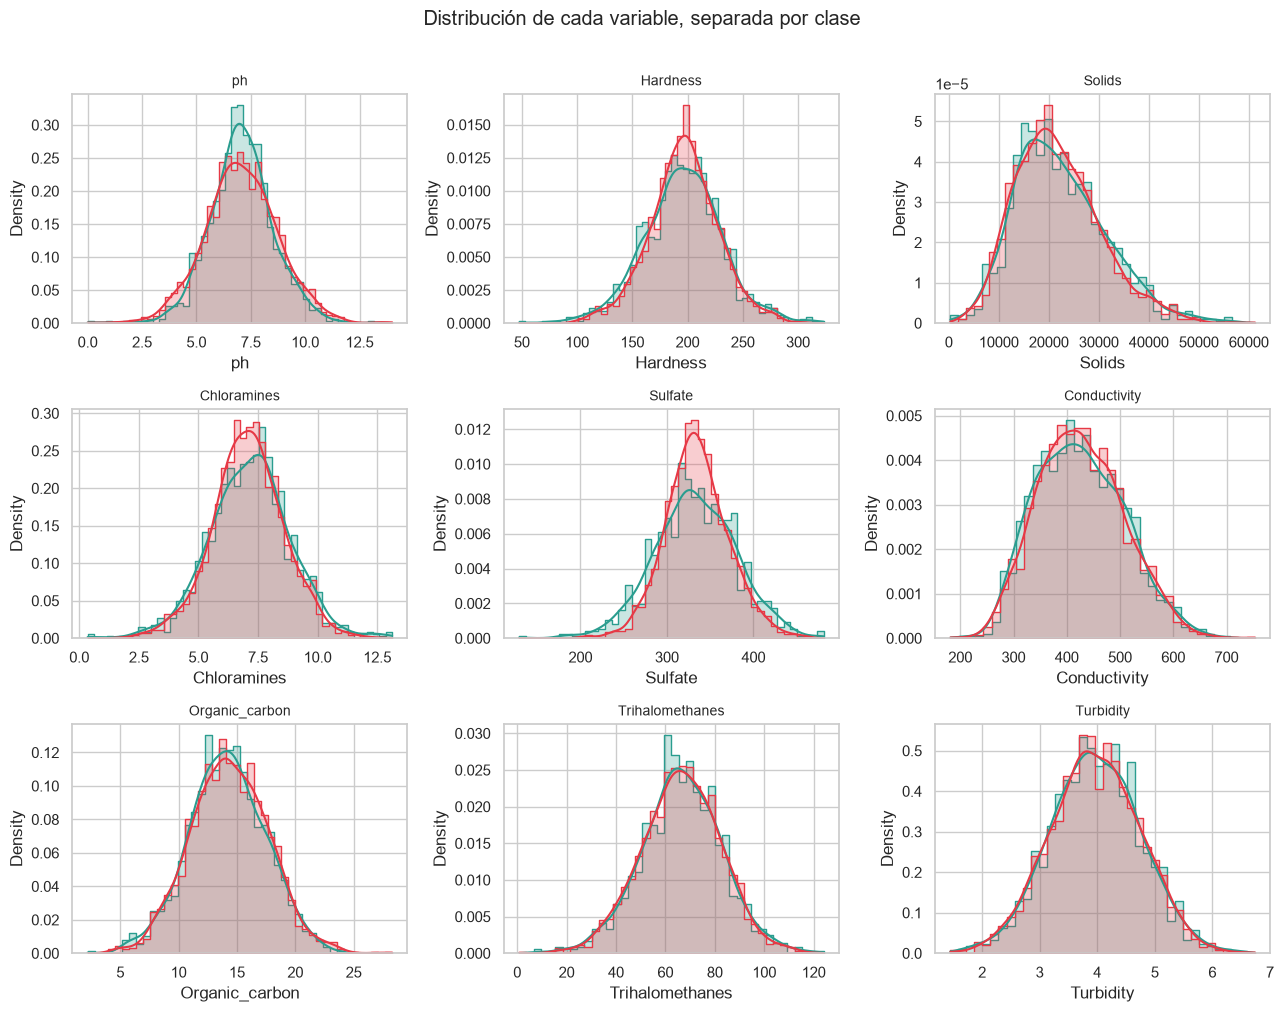

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(13, 10))
for ax, col in zip(axes.flat, FEATURES):
    sns.histplot(data=df, x=col, hue=TARGET, kde=True, ax=ax, palette=["#e63946", "#2a9d8f"],
                 legend=False, element="step", stat="density", common_norm=False)
    ax.set_title(col, fontsize=10)
plt.suptitle("Distribución de cada variable, separada por clase", y=1.01)
plt.tight_layout()
plt.show()

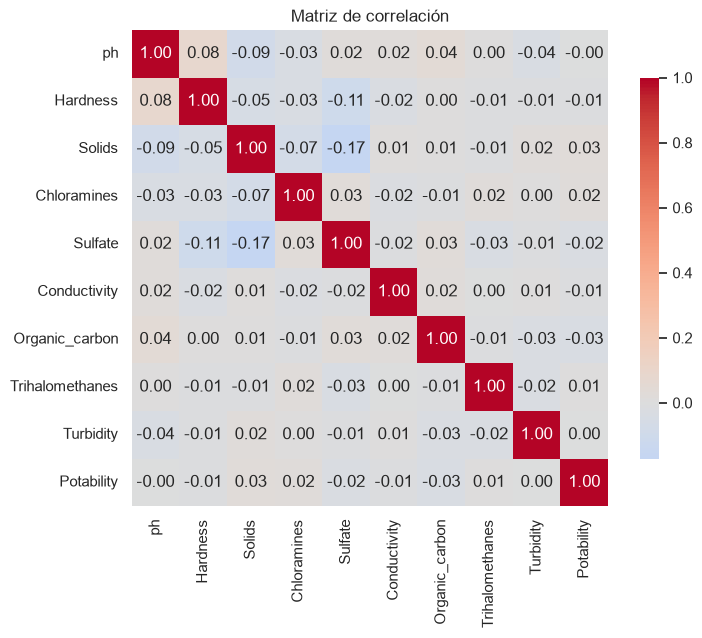

,correlación con Potability
Solids,0.033743
Organic_carbon,-0.030001
Chloramines,0.023779
Sulfate,-0.023577
Hardness,-0.013837
Conductivity,-0.008128
Trihalomethanes,0.007130
ph,-0.003556
Turbidity,0.001581


In [10]:
plt.figure(figsize=(8, 6.5))
corr = df[FEATURES + [TARGET]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True,
            cbar_kws={"shrink": 0.8})
plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

corr[TARGET].drop(TARGET).sort_values(key=abs, ascending=False).to_frame("correlación con Potability")

**Hallazgo clave:** ninguna variable individual tiene una relación lineal
fuerte con `Potability` — la correlación máxima en valor absoluto es apenas
0.034 (`Solids`). Esto anticipa que un modelo **lineal** como la regresión
logística tendrá una capacidad de clasificación limitada con estas variables
(se confirma en la sección 5).

## 3. Preprocesamiento

1. **Imputación de nulos:** `SimpleImputer(strategy="median")` para `ph`,
   `Sulfate` y `Trihalomethanes`. Se usa la mediana (no la media) porque es
   robusta ante los outliers vistos en los boxplots. El imputer se **ajusta
   solo con el conjunto de entrenamiento**, para evitar fuga de información
   hacia el conjunto de prueba.
2. **Estandarización:** `StandardScaler` sobre las 9 variables (media 0,
   desviación 1), también ajustado solo con train — necesario porque la
   regresión logística es sensible a la escala de las variables y porque así
   los coeficientes finales son comparables entre sí (sección 4.3).
3. **Codificación de variables categóricas:** no aplica — todas las variables
   son numéricas.
4. **División del dataset:** `train_test_split` 80/20 **estratificado** por
   `Potability`, dado el desbalance de clases observado.

Todo el preprocesamiento se implementa dentro de un único `sklearn.pipeline.Pipeline`
junto con el clasificador (sección 4), de modo que el modelo final sea
autocontenido: recibe datos crudos y aplica internamente imputación + escalado
antes de clasificar.

In [11]:
X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

preprocesador = ColumnTransformer(transformers=[
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]), FEATURES),
])

print(f"Entrenamiento: {X_train.shape[0]} muestras -> {y_train.value_counts().to_dict()}")
print(f"Prueba:        {X_test.shape[0]} muestras -> {y_test.value_counts().to_dict()}")

Entrenamiento: 2620 muestras -> {0: 1598, 1: 1022}
Prueba:        656 muestras -> {0: 400, 1: 256}


## 4. Modelado con Regresión Logística

### 4.1 La función sigmoide

La regresión logística modela la probabilidad de la clase positiva aplicando
la función **sigmoide** a una combinación lineal de las variables predictoras:

$$z = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_9 x_9$$

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

`σ(z)` comprime cualquier valor real `z` al intervalo (0, 1), interpretable
como la probabilidad de que la muestra sea potable. Se clasifica como
**Potable** si `σ(z) ≥ 0.5`, y **No potable** en caso contrario.

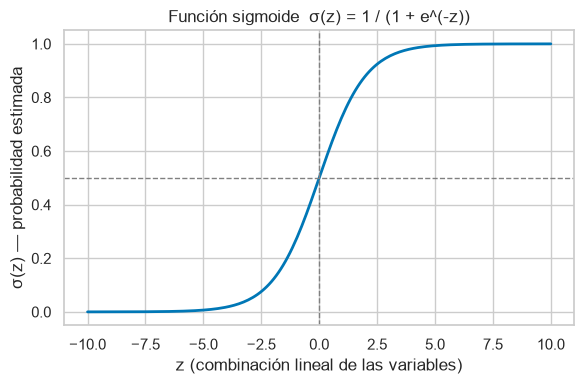

In [12]:
z = np.linspace(-10, 10, 200)
sigmoide = 1 / (1 + np.exp(-z))

plt.figure(figsize=(6, 4))
plt.plot(z, sigmoide, color="#0077b6", linewidth=2)
plt.axhline(0.5, color="gray", linestyle="--", linewidth=1)
plt.axvline(0, color="gray", linestyle="--", linewidth=1)
plt.title("Función sigmoide  σ(z) = 1 / (1 + e^(-z))")
plt.xlabel("z (combinación lineal de las variables)")
plt.ylabel("σ(z) — probabilidad estimada")
plt.tight_layout()
plt.show()

### 4.2 Configuración del modelo

| Hiperparámetro | Valor | Justificación |
|---|---|---|
| `solver` | `lbfgs` | Solver por defecto de scikit-learn, eficiente para este tamaño de dataset |
| `penalty` | `l2` | Regularización estándar para evitar sobreajuste |
| `class_weight` | `balanced` | El desbalance 61%/39% hace que el modelo sin ajustar prediga siempre la clase mayoritaria (Precision/Recall/F1 = 0 para "Potable" — se muestra abajo). Balancear los pesos corrige el umbral de decisión efectivo |
| `max_iter` | 1000 | Asegura convergencia del optimizador |
| `random_state` | 42 | Reproducibilidad |

In [13]:
# Primero, sin balancear -- para mostrar por que hace falta class_weight="balanced".
pipeline_sin_balancear = Pipeline([
    ("preprocesador", preprocesador),
    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])
pipeline_sin_balancear.fit(X_train, y_train)
pred_sin_balancear = pipeline_sin_balancear.predict(X_test)

print("Sin class_weight='balanced' -> el modelo clasifica siempre en la misma clase:")
print(pd.Series(pred_sin_balancear).value_counts())
print(f"Precision (clase Potable): {precision_score(y_test, pred_sin_balancear):.3f}")
print(f"Recall    (clase Potable): {recall_score(y_test, pred_sin_balancear):.3f}")

Sin class_weight='balanced' -> el modelo clasifica siempre en la misma clase:
0    656
Name: count, dtype: int64
Precision (clase Potable): 0.000
Recall    (clase Potable): 0.000


C:\Users\cuchu\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [14]:
# class_weight="balanced" es lo que efectivamente permite detectar la clase minoritaria.
pipeline = Pipeline([
    ("preprocesador", preprocesador),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
])
pipeline.fit(X_train, y_train)
print("Modelo entrenado.")

Modelo entrenado.


### 4.3 Análisis de coeficientes

Los coeficientes están en la escala **estandarizada** de las variables, por lo
que son directamente comparables entre sí (una magnitud mayor implica más
influencia en la clasificación, independientemente de las unidades originales).

In [15]:
coefs = pipeline.named_steps["clf"].coef_[0]
intercept = float(pipeline.named_steps["clf"].intercept_[0])

tabla_coefs = pd.Series(coefs, index=FEATURES).sort_values(key=abs, ascending=False)
print(f"Intercepto: {intercept:.4f}")
tabla_coefs.to_frame("coeficiente")

Intercepto: -0.0007


,coeficiente
Solids,0.059262
Chloramines,0.041254
Organic_carbon,-0.028628
ph,0.025634
Sulfate,-0.013301
Trihalomethanes,0.008194
Conductivity,0.006084
Turbidity,0.002418
Hardness,-0.002129


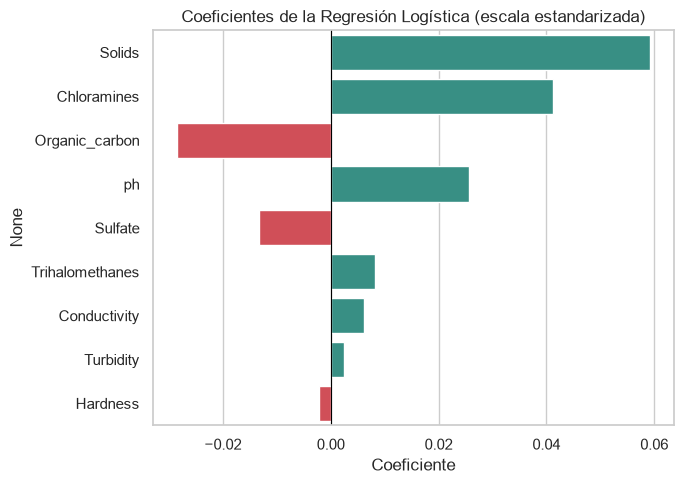

In [16]:
plt.figure(figsize=(7, 5))
colores = ["#2a9d8f" if v > 0 else "#e63946" for v in tabla_coefs.values]
sns.barplot(x=tabla_coefs.values, y=tabla_coefs.index, hue=tabla_coefs.index, palette=colores, legend=False)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Coeficientes de la Regresión Logística (escala estandarizada)")
plt.xlabel("Coeficiente")
plt.tight_layout()
plt.show()

La magnitud de todos los coeficientes es muy pequeña (< 0.06), consistente con
las correlaciones casi nulas observadas en el EDA (sección 2.3): ninguna
variable domina la clasificación, y el modelo en conjunto captura muy poca señal.

## 5. Evaluación de métricas

Todas las métricas se calculan sobre el **conjunto de prueba** (656 muestras,
no vistas durante el entrenamiento).

In [17]:
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=["No potable", "Potable"]))

              precision    recall  f1-score   support

  No potable       0.63      0.52      0.57       400
     Potable       0.41      0.53      0.47       256

    accuracy                           0.52       656
   macro avg       0.52      0.53      0.52       656
weighted avg       0.55      0.52      0.53       656



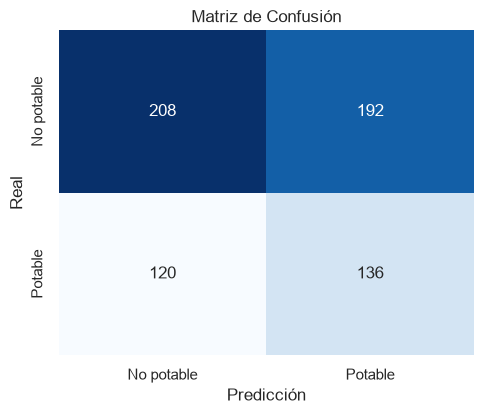

TN=208  FP=192  FN=120  TP=136


In [18]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

plt.figure(figsize=(5, 4.3))
cm = np.array([[tn, fp], [fn, tp]])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["No potable", "Potable"], yticklabels=["No potable", "Potable"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.tight_layout()
plt.show()

print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")

In [19]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

pd.DataFrame({
    "métrica": ["Accuracy", "Precision", "Recall", "F1-score", "AUC-ROC"],
    "valor": [accuracy, precision, recall, f1, auc],
}).style.format({"valor": "{:.4f}"})

,métrica,valor
0,Accuracy,0.5244
1,Precision,0.4146
2,Recall,0.5312
3,F1-score,0.4658
4,AUC-ROC,0.5474


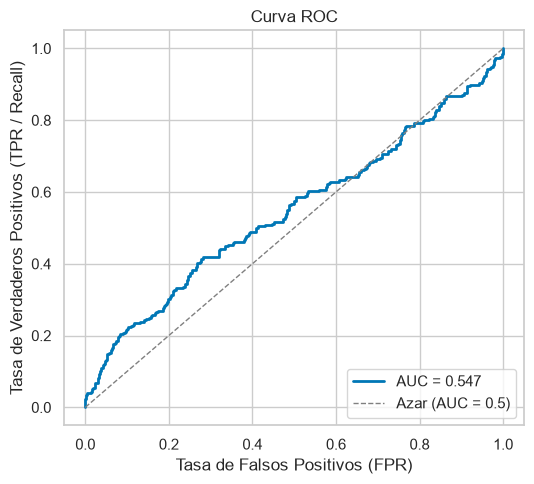

In [20]:
plt.figure(figsize=(5.5, 5))
plt.plot(fpr, tpr, color="#0077b6", linewidth=2, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1, label="Azar (AUC = 0.5)")
plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR / Recall)")
plt.title("Curva ROC")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

### 5.1 Interpretación operativa de los errores

La curva ROC está muy cerca de la diagonal de azar (AUC ≈ 0.547), confirmando
que el modelo apenas mejora una clasificación aleatoria. En el contexto de
potabilidad del agua, los dos tipos de error tienen **costos muy distintos**:

- **Falsos Negativos (FN):** agua realmente potable clasificada como no
  potable. El costo es principalmente **operativo**: se descarta o se
  reanaliza innecesariamente una fuente de agua segura.
- **Falsos Positivos (FP):** agua realmente no potable clasificada como
  potable. El costo es de **salud pública**, mucho más grave: se podría
  distribuir o consumir agua contaminada creyendo que es segura.

En este modelo, `FP > FN`: el ajuste por `class_weight="balanced"` mejoró la
sensibilidad hacia la clase "Potable" pero, como contrapartida, aumentó los
falsos positivos — precisamente el error más peligroso en este dominio. Esto
sugiere que, antes de cualquier uso operativo real, debería ajustarse el
**umbral de decisión** (por encima de 0.5) para privilegiar la detección de
agua no potable, aun a costa de accuracy global.

## 6. Exportación del modelo (despliegue)

El modelo se exporta en dos formatos, para dos aplicativos distintos:

1. **`modelo_potabilidad.pkl`** (joblib): el pipeline completo
   (imputer + scaler + regresión logística), consumido por la versión en
   Streamlit (`app.py`) desde Python.
2. **`app_web/modelo_potabilidad.json` / `.js`**: los mismos parámetros ya
   ajustados (medianas de imputación, media/desviación del escalado,
   coeficientes e intercepto), como datos planos consumidos por
   `app_web/clasificador.js` — un motor de inferencia genérico en JavaScript que
   hace imputación → estandarización → sigmoide **sin tener ningún
   coeficiente escrito a mano**. Si el modelo se reentrena, solo cambia este
   archivo de datos; el código JavaScript no se toca.

In [21]:
joblib.dump(pipeline, "modelo_potabilidad.pkl")

imputer_ajustado = pipeline.named_steps["preprocesador"].named_transformers_["num"].named_steps["imputer"]
scaler_ajustado = pipeline.named_steps["preprocesador"].named_transformers_["num"].named_steps["scaler"]

modelo_exportado = {
    "caso": "Taller 1.2 - Potabilidad del Agua | Regresion Logistica",
    "features": FEATURES,
    "descripcion": DESCRIPCION,
    "rangos_observados": {c: [float(df[c].min()), float(df[c].max())] for c in FEATURES},
    "imputacion_mediana_train": {c: float(v) for c, v in zip(FEATURES, imputer_ajustado.statistics_)},
    "escalado_train": {
        "media": {c: float(v) for c, v in zip(FEATURES, scaler_ajustado.mean_)},
        "desviacion": {c: float(v) for c, v in zip(FEATURES, scaler_ajustado.scale_)},
    },
    "regresion_logistica": {
        "intercepto": intercept,
        "coeficientes": {c: float(v) for c, v in zip(FEATURES, coefs)},
        "umbral_decision": 0.5,
        "clases": {"0": "No potable", "1": "Potable"},
    },
    "metricas_test": {
        "matriz_confusion": {"TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp)},
        "accuracy": accuracy, "precision": precision, "recall": recall,
        "f1_score": f1, "auc_roc": auc,
    },
}

with open("app_web/modelo_potabilidad.json", "w", encoding="utf-8") as f:
    json.dump(modelo_exportado, f, indent=2, ensure_ascii=False)

with open("app_web/modelo_potabilidad.js", "w", encoding="utf-8") as f:
    f.write("// Generado por train_model.py / este cuaderno - NO editar a mano.\n")
    f.write("const MODELO_POTABILIDAD = ")
    json.dump(modelo_exportado, f, indent=2, ensure_ascii=False)
    f.write(";\n")

print("Modelo exportado: modelo_potabilidad.pkl, app_web/modelo_potabilidad.json, app_web/modelo_potabilidad.js")
print(json.dumps(modelo_exportado["regresion_logistica"], indent=2))

Modelo exportado: modelo_potabilidad.pkl, app_web/modelo_potabilidad.json, app_web/modelo_potabilidad.js
{
  "intercepto": -0.0007289857024894229,
  "coeficientes": {
    "ph": 0.025633913883333206,
    "Hardness": -0.0021286694642798803,
    "Solids": 0.05926248935414956,
    "Chloramines": 0.041254494161276266,
    "Sulfate": -0.013301112270649042,
    "Conductivity": 0.006084000779433002,
    "Organic_carbon": -0.028627716296217638,
    "Trihalomethanes": 0.00819386098334667,
    "Turbidity": 0.002418139953815675
  },
  "umbral_decision": 0.5,
  "clases": {
    "0": "No potable",
    "1": "Potable"
  }
}


### 6.1 Motor de inferencia en el navegador (`app_web/clasificador.js`)

Fragmento del motor de inferencia genérico que consume el archivo anterior
(no reimplementa la fórmula con números hardcodeados; recorre
`modelo.features` y usa los coeficientes que carga):

```js
function clasificar(valoresCrudos, modelo) {
  const { features, imputacion_mediana_train, escalado_train, regresion_logistica } = modelo;
  const { intercepto, coeficientes, umbral_decision, clases } = regresion_logistica;

  let z = intercepto;
  for (const feature of features) {
    let x = valoresCrudos[feature];
    if (x === null || x === undefined || Number.isNaN(Number(x))) {
      x = imputacion_mediana_train[feature];        // misma mediana del train
    }
    const xEstandarizado = (x - escalado_train.media[feature]) / escalado_train.desviacion[feature];
    z += coeficientes[feature] * xEstandarizado;
  }

  const probabilidad = 1 / (1 + Math.exp(-z));       // sigmoide
  const clase = probabilidad >= umbral_decision ? 1 : 0;
  return { clase, etiqueta: clases[String(clase)], probabilidad };
}
```

`app_web/index.html` construye el formulario dinámicamente a partir de
`modelo.features`, y usa esta función para clasificar en el navegador sin
backend. Se verificó que reproduce exactamente los mismos resultados que este
cuaderno y que la app en Streamlit, sobre los mismos casos de prueba.

## 7. Conclusiones y recomendaciones

- El modelo de regresión logística alcanza un desempeño apenas superior al
  azar (AUC ≈ 0.547, Accuracy ≈ 52.4%), lo que indica que las 9 variables
  fisicoquímicas disponibles en este dataset tienen una relación débil —y
  probablemente no lineal— con la potabilidad real medida en laboratorio.
  Esta limitación ya era visible en el EDA (sección 2.3): ninguna variable
  individual supera |r| = 0.034 de correlación con el target.
- El ajuste por `class_weight="balanced"` fue necesario para obtener un
  clasificador que efectivamente distinga ambas clases (sin él, el modelo
  clasificaba siempre como "no potable", sección 4.2), pero desplazó el error hacia
  más falsos positivos, el tipo de error más costoso en este dominio
  (sección 5.1).
- **Recomendaciones para trabajo futuro:**
  1. Evaluar modelos no lineales (Random Forest, Gradient Boosting, SVM con
     kernel RBF) que puedan capturar interacciones entre variables no
     accesibles a un modelo lineal.
  2. Incorporar ingeniería de atributos (razones e interacciones entre
     variables, p. ej. pH × Cloraminas).
  3. Ajustar el umbral de decisión de forma explícita para minimizar falsos
     positivos, dado el costo asimétrico de los errores en salud pública.
  4. De ser posible, ampliar el dataset con variables adicionales
     (indicadores bacteriológicos, metales pesados) que suelen tener mayor
     poder de clasificación sobre la potabilidad real.

**Repositorio:** [github.com/JigSaw1117/CLAUDIOS](https://github.com/JigSaw1117/CLAUDIOS) — carpeta `TALLER 1.2/`.
**Dataset:** [Water Potability — Kaggle](https://www.kaggle.com/datasets/adityakadiwal/water-potability).